# Module 4 — Feature Engineering
Risk-signal features + a **saved** preprocessor, built with strict anti-leakage
ordering. All logic lives in `src/features.py` so training and serving transform
data identically.

**The rule that makes or breaks this module:** split *first*, then resample —
SMOTE / class-weights touch the **train fold only**, and the scaler/encoder are
**fit on train only**. Anything else silently inflates the scores.

In [1]:
import sys
from pathlib import Path
here = Path.cwd()
root = here if (here / "src").exists() else here.parent
sys.path.insert(0, str(root / "src"))

import numpy as np, pandas as pd, joblib
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import mutual_info_classif
from imblearn.over_sampling import SMOTE
from config import DATA_PROCESSED, FIGURES, SEED
from features import (engineer_features, build_preprocessor, model_feature_columns,
                      transformed_feature_names, TARGET)
sns.set_theme(style="whitegrid")

df = pd.read_parquet(DATA_PROCESSED / "transactions_clean.parquet")
df = engineer_features(df)
print(f"{len(df):,} rows, {df.shape[1]} columns after feature engineering")

2,770,409 rows, 36 columns after feature engineering


## 1. Engineered features
- **Balance/error:** `errorBalanceOrig`, `errorBalanceDest`, `origin_emptied`, `amount_to_oldbalanceOrg`
- **Amount:** `log_amount`
- **Geo:** `ip_country_mismatch` (+ existing `ip_billing_distance_km`)
- **Velocity (causal — only prior transactions per account):**
  `orig_prior_txn_count`, `orig_time_since_last`, `is_first_orig_txn`,
  `dest_prior_txn_count`, `dest_prior_amount_sum`

Causality matters: each velocity value uses only earlier `step`s, so it never
peeks at the future and is reproducible at serving time from account history.

In [2]:
new_cols = ["errorBalanceOrig","errorBalanceDest","origin_emptied","amount_to_oldbalanceOrg",
            "log_amount","ip_country_mismatch","orig_prior_txn_count","orig_time_since_last",
            "is_first_orig_txn","dest_prior_txn_count","dest_prior_amount_sum"]
display(df[new_cols].describe().T[["mean","std","min","max"]])

,mean,std,min,max
errorBalanceOrig,-2.859850e+05,8.753230e+05,-92445516.64,1.000000e-02
errorBalanceDest,-2.864713e+04,5.934794e+05,-75885725.63,1.000000e+07
origin_emptied,2.896684e-03,5.374286e-02,0.00,1.000000e+00
amount_to_oldbalanceOrg,1.577019e+05,7.615423e+05,0.00,9.244552e+07
log_amount,1.192780e+01,1.232817e+00,0.00,1.834213e+01
ip_country_mismatch,6.455040e-02,2.457309e-01,0.00,1.000000e+00
orig_prior_txn_count,6.432263e-04,2.539643e-02,0.00,2.000000e+00
orig_time_since_last,-8.978396e-01,5.117695e+00,-1.00,7.000000e+02
is_first_orig_txn,9.993579e-01,2.533242e-02,0.00,1.000000e+00
dest_prior_txn_count,5.291217e+00,6.011013e+00,0.00,7.400000e+01


## 2. Stratified split — BEFORE anything else
Stratifying preserves the ~0.3% fraud rate in both folds (critical at this
imbalance — a random split could starve the test set of fraud).

In [3]:
feat = model_feature_columns()
X, y = df[feat], df[TARGET]
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25,
                                          random_state=SEED, stratify=y)
print(f"train {len(X_tr):,}  fraud {y_tr.sum():,} ({y_tr.mean()*100:.3f}%)")
print(f"test  {len(X_te):,}  fraud {y_te.sum():,} ({y_te.mean()*100:.3f}%)")

train 2,077,806  fraud 6,160 (0.296%)
test  692,603  fraud 2,053 (0.296%)


## 3. Fit the preprocessor on TRAIN ONLY, then save it
Scale numerics, pass binary flags through, one-hot `type`. Fitting on train only
means the scaler's mean/std never see test data. The saved artifact is what the
deployment API will reload — same transform, no train/serve skew.

In [4]:
pre = build_preprocessor()
pre.fit(X_tr)                      # <-- train only
Xtr_t = pre.transform(X_tr)
Xte_t = pre.transform(X_te)        # test transformed with train-fitted stats
names = transformed_feature_names(pre)
print("transformed feature count:", Xtr_t.shape[1])
# evidence scaler used train stats: train col-mean ~0, test col-mean generally != 0
print("scaled TRAIN col-0 mean:", round(float(Xtr_t[:,0].mean()), 4),
      "| TEST col-0 mean:", round(float(Xte_t[:,0].mean()), 4))

transformed feature count: 28
scaled TRAIN col-0 mean: 0.0 | TEST col-0 mean: 0.0016


## 4. Class imbalance — handled on the training fold only
Two complementary levers (Module 5 will compare them):
- **Class weights / `scale_pos_weight = n_neg/n_pos`** — no data duplication.
- **SMOTE** — synthesise minority examples, applied to the **transformed train
  set only**. Never resample test: test must reflect the real ~0.3% prevalence.

scale_pos_weight (n_neg/n_pos) = 336.3


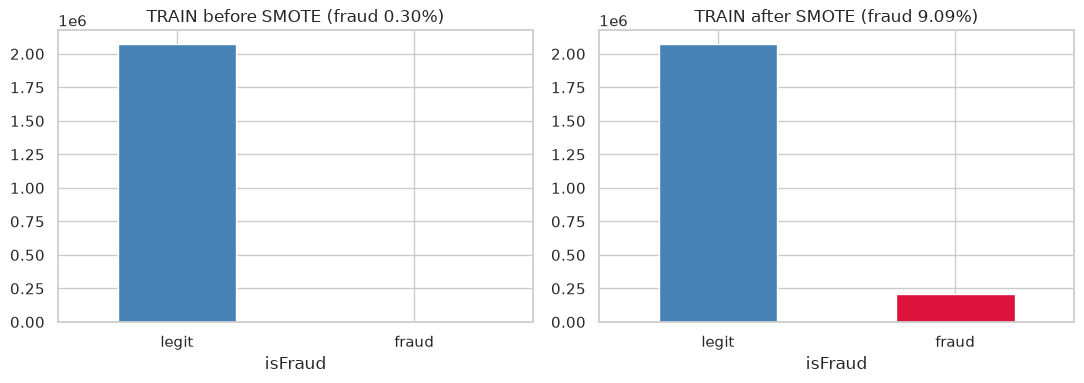

test fraud rate unchanged: 0.296%


In [5]:
pos, neg = int(y_tr.sum()), int((~y_tr.astype(bool)).sum())
scale_pos_weight = neg / max(pos, 1)
print(f"scale_pos_weight (n_neg/n_pos) = {scale_pos_weight:,.1f}")

sm = SMOTE(sampling_strategy=0.1, random_state=SEED)   # minority -> 10% of train
Xtr_res, ytr_res = sm.fit_resample(Xtr_t, y_tr)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
pd.Series(y_tr).value_counts().plot.bar(ax=ax[0], color=["steelblue","crimson"])
ax[0].set_title(f"TRAIN before SMOTE (fraud {y_tr.mean()*100:.2f}%)")
pd.Series(ytr_res).value_counts().plot.bar(ax=ax[1], color=["steelblue","crimson"])
ax[1].set_title(f"TRAIN after SMOTE (fraud {ytr_res.mean()*100:.2f}%)")
for a in ax: a.set_xticklabels(["legit","fraud"], rotation=0)
plt.tight_layout(); plt.savefig(FIGURES/"smote_train_only.png", dpi=150, bbox_inches="tight"); plt.show()
print(f"test fraud rate unchanged: {y_te.mean()*100:.3f}%")

## 5. Feature selection — mutual information (train subsample)
MI captures non-linear dependence, so it ranks the balance/velocity signals
properly (unlike Pearson). Absolute MI is small under extreme imbalance — the
**ranking** is what matters. We keep all features (trees tolerate weak ones) and
use this to justify the top signals.

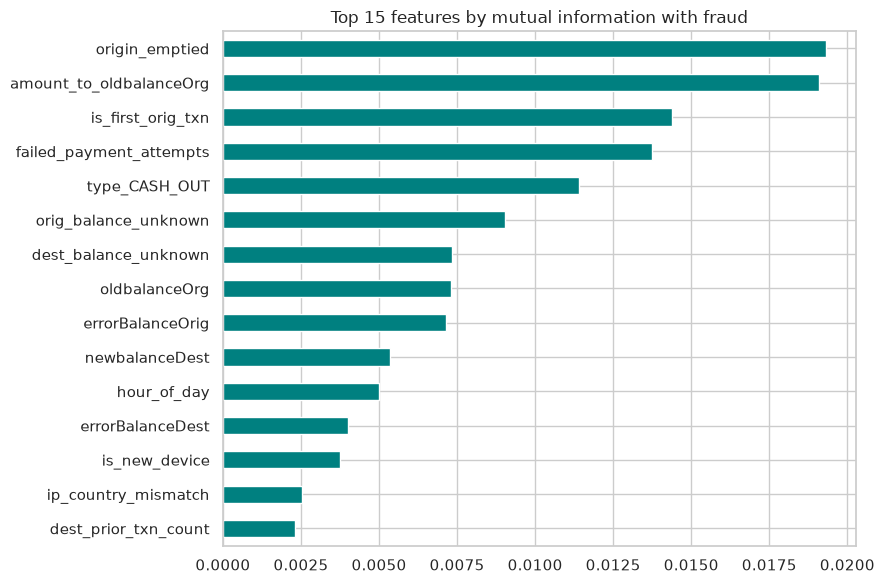

origin_emptied             0.01931
amount_to_oldbalanceOrg    0.01908
is_first_orig_txn          0.01439
failed_payment_attempts    0.01376
type_CASH_OUT              0.01141
orig_balance_unknown       0.00905
dest_balance_unknown       0.00735
oldbalanceOrg              0.00731
errorBalanceOrig           0.00714
newbalanceDest             0.00534
hour_of_day                0.00501
errorBalanceDest           0.00399
is_new_device              0.00375
ip_country_mismatch        0.00254
dest_prior_txn_count       0.00232
dtype: float64

In [6]:
sub = X_tr.sample(min(50_000, len(X_tr)), random_state=SEED)
mi = mutual_info_classif(pre.transform(sub), y_tr.loc[sub.index],
                         discrete_features=False, random_state=SEED)
mi_rank = pd.Series(mi, index=names).sort_values(ascending=False)

plt.figure(figsize=(9, 6))
mi_rank.head(15).iloc[::-1].plot.barh(color="teal")
plt.title("Top 15 features by mutual information with fraud")
plt.tight_layout(); plt.savefig(FIGURES/"mutual_information.png", dpi=150, bbox_inches="tight"); plt.show()
display(mi_rank.head(15).round(5))

## 6. Sanity-check the top engineered features by fraud rate

In [7]:
df["amt_bal_ratio_bucket"] = pd.cut(df["amount_to_oldbalanceOrg"],
        [-0.01, 0.5, 0.95, 1.05, 1e9], labels=["<0.5","0.5-0.95","~1.0",">1.05"])
print("fraud rate by origin_emptied (%):")
display(df.groupby("origin_emptied")["isFraud"].mean().mul(100).round(4))
print("fraud rate by amount/oldbalanceOrg bucket (%):")
display(df.groupby("amt_bal_ratio_bucket")["isFraud"].mean().mul(100).round(4))

fraud rate by origin_emptied (%):


origin_emptied
0     0.0068
1    99.9875
Name: isFraud, dtype: float64

fraud rate by amount/oldbalanceOrg bucket (%):


amt_bal_ratio_bucket
<0.5         0.0441
0.5-0.95     0.0851
~1.0        28.3704
>1.05        0.0012
Name: isFraud, dtype: float64

## 7. Artifacts & next steps
`src/build_features.py` persists everything Module 5 consumes:
`models/preprocessor.joblib`, `models/feature_config.json`,
`data/processed/split/train.parquet`, `data/processed/split/test.parquet`.

**Module 5 (Modelling):** train Logistic Regression, Random Forest, XGBoost/
LightGBM using `class_weight`/`scale_pos_weight` and the SMOTE option; evaluate
with **AUC-PR**, precision/recall, F1; then pick the operating threshold that
minimises the business **cost** (missed-fraud value vs false-alarm cost).